# Guía 6 — Redes Bayesianas aplicadas al Rendimiento Deportivo

**Curso:** Inteligencia Artificial
**Integrantes:** Keiry Lucía Olaya Noguera · Harold Stiven Camargo Castellanos · Juan Felipe Coronel Montes
**Sector:** Rendimiento deportivo y analítica avanzada (fútbol profesional)

---

## El problema

En la **Guía 5** modelamos la preparación del atleta con **Min-Max**: el cuerpo técnico (MAX) elige
la carga de entrenamiento y el organismo (MIN) responde con un nivel de fatiga. Min-Max asume que
el organismo es un **adversario perfecto**: que *siempre* responderá con la fatiga que más nos
perjudique.

Pero eso no es cierto. El organismo no es un rival: es un sistema **incierto**. A veces una carga
alta deja al atleta fresco y a veces una carga moderada lo deja fundido.

> **La pregunta de esta guía:** ¿qué tan probable es realmente cada respuesta del organismo, y cómo
> cambia nuestra expectativa de éxito cuando los sensores nos dan evidencia?

Para eso usamos una **Red Bayesiana**, que es exactamente el tercer pilar de la IA clásica:

| Método | Supuesto del mundo | Guía |
|---|---|---|
| STRIPS | Determinista: todo ocurre como se planifica | 5 |
| Min-Max | Competitivo: el rival siempre juega lo mejor posible | 5 |
| **Redes Bayesianas** | **Incierto: todo tiene probabilidad** | **6 (esta)** |

---

## Objetivos de la actividad

1. **Construcción de la red:** identificar tres variables principales, dibujar la red con sus
   dependencias y definir las probabilidades previas y condicionales (CPTs).
2. **Probabilidad conjunta:** calcular la probabilidad conjunta de un escenario específico e
   interpretarla.
3. **Inferencia con evidencia parcial:** calcular la probabilidad de un evento final dado un factor
   conocido, y explicar cómo cambia la expectativa.

*(Al final añadimos dos secciones complementarias: los tres tipos de razonamiento del material de
clase, y la conexión numérica con el Min-Max de la Guía 5.)*

In [1]:
# ============================================================
# CELDA 1 — Importaciones y paleta de colores
# ============================================================
# Se usan unicamente librerias estandar de analisis y graficos.
# El calculo bayesiano se hace A MANO, con diccionarios, tal como
# los ejemplos resueltos del material de clase. No se usa ninguna
# libreria de redes bayesianas: el objetivo es poder mostrar el
# paso a paso del Teorema de Bayes.
# ============================================================

from itertools import product

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Paleta de colores (la misma de la Guia 5)
ROJO     = "#E74C3C"
VERDE    = "#27AE60"
AZUL     = "#2980B9"
AMARILLO = "#F1C40F"
GRIS     = "#95A5A6"
NARANJA  = "#E67E22"
MORADO   = "#8E44AD"

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Librerias cargadas correctamente.")

ModuleNotFoundError: No module named 'matplotlib'

---

# 1. Construcción de la red

## 1.1 Las tres variables

Elegimos las variables de modo que sean **las mismas del árbol Min-Max de la Guía 5**. Esto no es
casualidad: queremos que los tres métodos hablen del mismo mundo y que los números de uno se puedan
contrastar con los del otro.

| Variable | Significado | Valores | Origen del dato | Rol en la Guía 5 |
|---|---|---|---|---|
| **C** | Carga de entrenamiento aplicada en la semana | `Alta` / `Moderada` | Decisión del cuerpo técnico | **Nivel 1 del árbol (MAX)** |
| **F** | Fatiga con la que responde el organismo | `Alta` / `Baja` | HRV, sueño y carga GPS/IMU (Kinexon) | **Nivel 2 del árbol (MIN)** |
| **E** | Éxito competitivo (llega disponible y rinde) | `Exito` / `Fallo` | Registro histórico de disponibilidad y rendimiento | Resultado |

## 1.2 La red y sus dependencias

```
             C  (Carga semanal)
            / \
           /   \
          v     v
         F ────> E
     (Fatiga)   (Éxito competitivo)
```

**Justificación de cada arco** (esto es lo que hay que poder defender, no los números):

- **`C → F`** — Una carga alta hace mucho más probable que el atleta llegue fatigado. Es la relación
  que miden los chalecos GPS todos los días: a más carga acumulada, peor variabilidad de la
  frecuencia cardíaca.
- **`C → E`** — La carga afecta el rendimiento **por un camino que no pasa por la fatiga**: entrenar
  poco deja al atleta sin ritmo competitivo aunque esté descansado.
- **`F → E`** — Un atleta fatigado rinde peor y se lesiona más, venga esa fatiga de donde venga.

Que `E` tenga **dos padres** es lo que hace que su CPT tenga 4 filas, exactamente como la tabla
`P(Actividad | Clima, Transporte)` del ejemplo de clase.

## 1.3 Las CPTs

Los valores son **estimaciones del cuerpo técnico a partir del histórico de disponibilidad del
plantel**. Están elegidos para que el orden de las probabilidades coincida con el orden de las
utilidades que calculamos en la Guía 5: la combinación `Carga Moderada + Fatiga Baja` es la mejor
(allí valía **+42**) y `Carga Alta + Fatiga Alta` es la peor (allí valía **−27**).

In [ ]:
# ============================================================
# CELDA 2 — Variables y Tablas de Probabilidad Condicional (CPT)
# ============================================================
# Estructura de la red:
#
#          C  (Carga semanal)
#         / \
#        v   v
#       F --> E
#
# Se definen 3 CPTs, igual que en el ejemplo de clase:
#   1. P(C)        -> distribucion previa (no depende de nadie)
#   2. P(F | C)    -> la fatiga depende de la carga
#   3. P(E | C, F) -> el exito depende de ambas
#
# CAMBIAR CUALQUIER VALOR DE AQUI Y VOLVER A EJECUTAR EL NOTEBOOK
# RECALCULA TODOS LOS RESULTADOS Y TODAS LAS GRAFICAS.
# ============================================================

VALORES_C = ["Alta", "Moderada"]
VALORES_F = ["Alta", "Baja"]
VALORES_E = ["Exito", "Fallo"]

# ── CPT 1: P(C) — probabilidad previa de la carga semanal ────
# Historico: 4 de cada 10 semanas el cuerpo tecnico aplica carga alta.
P_C = {
    "Alta":     0.40,
    "Moderada": 0.60,
}

# ── CPT 2: P(F | C) — la fatiga depende de la carga ──────────
# Con carga alta el atleta llega fatigado 3 de cada 4 veces.
# Con carga moderada, solo 3 de cada 10.
P_F_dado_C = {
    "Alta":     {"Alta": 0.75, "Baja": 0.25},
    "Moderada": {"Alta": 0.30, "Baja": 0.70},
}

# ── CPT 3: P(E | C, F) — el exito depende de carga y fatiga ──
# Cuatro filas porque E tiene dos padres.
P_E_dado_CF = {
    ("Alta",     "Alta"): {"Exito": 0.25, "Fallo": 0.75},
    ("Alta",     "Baja"): {"Exito": 0.65, "Fallo": 0.35},
    ("Moderada", "Alta"): {"Exito": 0.45, "Fallo": 0.55},
    ("Moderada", "Baja"): {"Exito": 0.85, "Fallo": 0.15},
}


# ── Impresion de las tres CPTs ───────────────────────────────
print("=" * 62)
print("  CPT 1 — P(C)  Probabilidad previa de la carga semanal")
print("=" * 62)
print(pd.DataFrame([{"C": c, "P(C)": p} for c, p in P_C.items()])
      .to_string(index=False))

print()
print("=" * 62)
print("  CPT 2 — P(F | C)  La fatiga depende de la carga")
print("=" * 62)
print(pd.DataFrame([
    {"C": c, "P(F=Alta|C)": d["Alta"], "P(F=Baja|C)": d["Baja"]}
    for c, d in P_F_dado_C.items()
]).to_string(index=False))

print()
print("=" * 62)
print("  CPT 3 — P(E | C, F)  El exito depende de ambas")
print("=" * 62)
print(pd.DataFrame([
    {"C": c, "F": f,
     "P(E=Exito|C,F)": d["Exito"], "P(E=Fallo|C,F)": d["Fallo"]}
    for (c, f), d in P_E_dado_CF.items()
]).to_string(index=False))


# ── Validacion: toda distribucion debe sumar 1 ───────────────
print()
print("Validacion de las CPTs (toda distribucion debe sumar 1.0):")
ok = True
if abs(sum(P_C.values()) - 1) > 1e-9:
    ok = False; print("  ERROR en P(C)")
for c, d in P_F_dado_C.items():
    if abs(sum(d.values()) - 1) > 1e-9:
        ok = False; print(f"  ERROR en P(F|C={c})")
for k, d in P_E_dado_CF.items():
    if abs(sum(d.values()) - 1) > 1e-9:
        ok = False; print(f"  ERROR en P(E|C,F={k})")
print("  Todas las distribuciones suman 1.0" if ok else "  HAY ERRORES")

  CPT 1 — P(C)  Probabilidad previa de la carga semanal
       C  P(C)
    Alta   0.4
Moderada   0.6

  CPT 2 — P(F | C)  La fatiga depende de la carga
       C  P(F=Alta|C)  P(F=Baja|C)
    Alta         0.75         0.25
Moderada         0.30         0.70

  CPT 3 — P(E | C, F)  El exito depende de ambas
       C    F  P(E=Exito|C,F)  P(E=Fallo|C,F)
    Alta Alta            0.25            0.75
    Alta Baja            0.65            0.35
Moderada Alta            0.45            0.55
Moderada Baja            0.85            0.15

Validacion de las CPTs (toda distribucion debe sumar 1.0):
  Todas las distribuciones suman 1.0


## 1.4 Dibujo de la red bayesiana

Un grafo **dirigido y acíclico (DAG)**: las flechas indican *"influye en"*, y nunca se puede volver
al punto de partida siguiendo flechas.

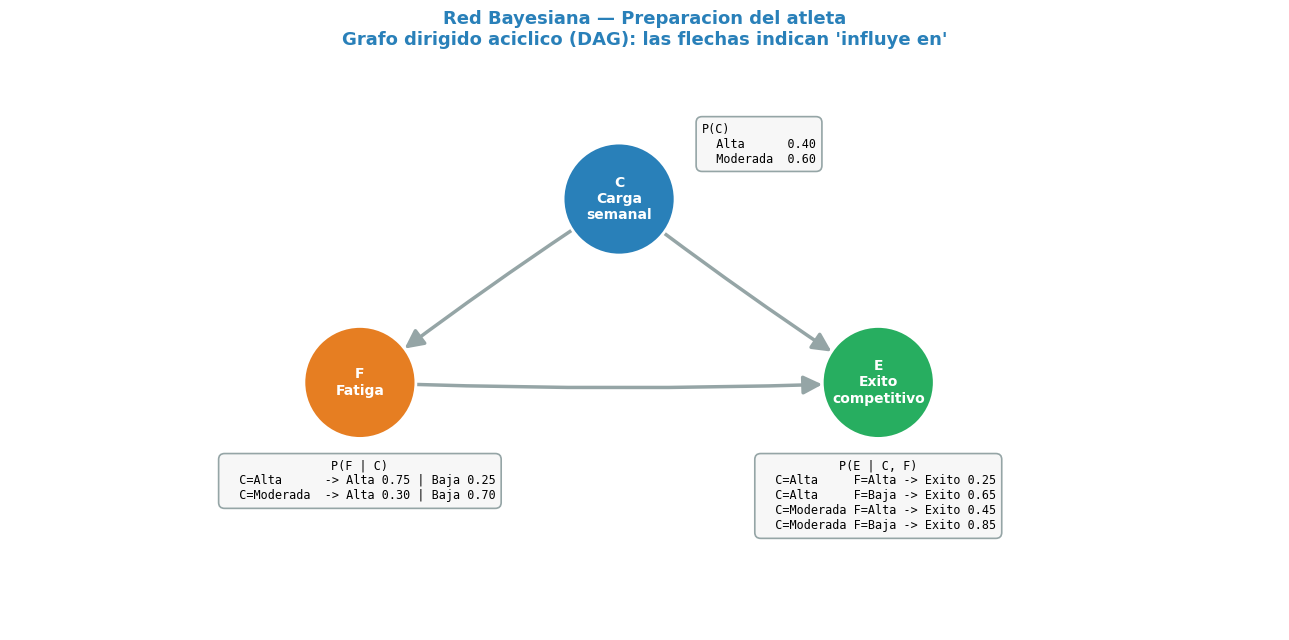

Figura guardada como 'red_bayesiana.png'


In [ ]:
# ============================================================
# CELDA 3 — Dibujo de la red bayesiana con sus CPTs
# ============================================================
# Nodos  = variables aleatorias
# Flechas = dependencia probabilistica ("influye en")
# Junto a cada nodo se anota su tabla de probabilidad.
# ============================================================

G = nx.DiGraph()
G.add_edges_from([("C", "F"), ("C", "E"), ("F", "E")])

pos = {"C": (0.0, 1.0), "F": (-1.0, 0.0), "E": (1.0, 0.0)}

etiquetas_nodos = {
    "C": "C\nCarga\nsemanal",
    "F": "F\nFatiga",
    "E": "E\nExito\ncompetitivo",
}

fig, ax = plt.subplots(figsize=(13, 6.5))

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=6500,
                       node_color=[AZUL, NARANJA, VERDE],
                       edgecolors="white", linewidths=2)
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=28,
                       width=2.5, edge_color=GRIS,
                       node_size=6500, connectionstyle="arc3,rad=0.02")
nx.draw_networkx_labels(G, pos, labels=etiquetas_nodos, ax=ax,
                        font_size=10, font_weight="bold",
                        font_color="white")

# ── CPTs anotadas junto a cada nodo ─────────────────────────
tabla_C = ("P(C)\n"
           f"  Alta      {P_C['Alta']:.2f}\n"
           f"  Moderada  {P_C['Moderada']:.2f}")

tabla_F = ("P(F | C)\n"
           "  C=Alta      -> Alta {:.2f} | Baja {:.2f}\n"
           "  C=Moderada  -> Alta {:.2f} | Baja {:.2f}").format(
    P_F_dado_C["Alta"]["Alta"], P_F_dado_C["Alta"]["Baja"],
    P_F_dado_C["Moderada"]["Alta"], P_F_dado_C["Moderada"]["Baja"])

tabla_E = "P(E | C, F)\n" + "\n".join(
    f"  C={c:<8} F={f:<4} -> Exito {P_E_dado_CF[(c, f)]['Exito']:.2f}"
    for c, f in product(VALORES_C, VALORES_F))

caja = dict(boxstyle="round,pad=0.5", facecolor="#F7F7F7",
            edgecolor=GRIS, linewidth=1.2)

ax.text(0.32, 1.30, tabla_C, fontsize=8.5, family="monospace",
        va="center", ha="left", bbox=caja)
ax.text(-1.00, -0.42, tabla_F, fontsize=8.5, family="monospace",
        va="top", ha="center", bbox=caja)
ax.text(1.00, -0.42, tabla_E, fontsize=8.5, family="monospace",
        va="top", ha="center", bbox=caja)

ax.set_title("Red Bayesiana — Preparacion del atleta\n"
             "Grafo dirigido aciclico (DAG): las flechas indican 'influye en'",
             fontsize=13, fontweight="bold", color=AZUL, pad=16)
ax.set_xlim(-2.35, 2.55)
ax.set_ylim(-1.35, 1.72)
ax.axis("off")
plt.tight_layout()
plt.savefig("red_bayesiana.png", dpi=130, bbox_inches="tight")
plt.show()

print("Figura guardada como 'red_bayesiana.png'")

---

# 2. Probabilidad conjunta

## 2.1 La regla de factorización

Una red bayesiana permite calcular la probabilidad de **cualquier combinación completa** de valores
multiplicando la CPT de cada nodo, evaluada en el valor de sus padres:

$$P(C, F, E) = P(C)\cdot P(F \mid C)\cdot P(E \mid C, F)$$

Esto es lo que hace útil a una red bayesiana. Sin ella necesitaríamos una tabla gigante con la
probabilidad de cada combinación posible. Con ella, basta con 3 tablas pequeñas.

> **Analogía:** es como una receta. En vez de memorizar el sabor final de los 8 platos posibles,
> memorizas qué aporta cada ingrediente y multiplicas.

In [ ]:
# ============================================================
# CELDA 4 — Distribucion conjunta completa
# ============================================================
# Se calculan las 8 combinaciones posibles (2 x 2 x 2) aplicando
# la factorizacion:
#
#     P(C, F, E) = P(C) * P(F|C) * P(E|C,F)
#
# La suma de las 8 debe dar exactamente 1.0
# ============================================================

def p_conjunta(c, f, e):
    """Probabilidad conjunta de una combinacion completa (c, f, e)."""
    return P_C[c] * P_F_dado_C[c][f] * P_E_dado_CF[(c, f)][e]


filas = []
for c, f, e in product(VALORES_C, VALORES_F, VALORES_E):
    filas.append({
        "C": c, "F": f, "E": e,
        "P(C)":        P_C[c],
        "P(F|C)":      P_F_dado_C[c][f],
        "P(E|C,F)":    P_E_dado_CF[(c, f)][e],
        "P(C,F,E)":    round(p_conjunta(c, f, e), 5),
    })

tabla_conjunta = pd.DataFrame(filas)

print("=" * 78)
print("  DISTRIBUCION CONJUNTA COMPLETA — P(C, F, E)")
print("=" * 78)
print(tabla_conjunta.to_string(index=False))

suma = tabla_conjunta["P(C,F,E)"].sum()
print("-" * 78)
print(f"  SUMA TOTAL = {suma:.5f}   ->  "
      f"{'CORRECTO: la distribucion es valida' if abs(suma - 1) < 1e-9 else 'ERROR'}")

  DISTRIBUCION CONJUNTA COMPLETA — P(C, F, E)
       C    F     E  P(C)  P(F|C)  P(E|C,F)  P(C,F,E)
    Alta Alta Exito   0.4    0.75      0.25     0.075
    Alta Alta Fallo   0.4    0.75      0.75     0.225
    Alta Baja Exito   0.4    0.25      0.65     0.065
    Alta Baja Fallo   0.4    0.25      0.35     0.035
Moderada Alta Exito   0.6    0.30      0.45     0.081
Moderada Alta Fallo   0.6    0.30      0.55     0.099
Moderada Baja Exito   0.6    0.70      0.85     0.357
Moderada Baja Fallo   0.6    0.70      0.15     0.063
------------------------------------------------------------------------------
  SUMA TOTAL = 1.00000   ->  CORRECTO: la distribucion es valida


## 2.2 El escenario que pide la actividad

La actividad pide calcular la probabilidad conjunta de un escenario específico
(`P(X="positivo", Y="favorable", Z="éxito")`). En nuestro contexto, el escenario equivalente es
**el ideal**:

$$P(C=\text{Moderada},\; F=\text{Baja},\; E=\text{Exito})$$

*"Aplicamos carga moderada, el cuerpo respondió fresco y el atleta rindió en el partido."*

In [ ]:
# ============================================================
# CELDA 5 — Probabilidad conjunta del escenario pedido
# ============================================================
# Se resuelve paso a paso, con el mismo formato de los ejemplos
# resueltos del material de clase.
# ============================================================

def mostrar_conjunta(c, f, e, titulo):
    pc  = P_C[c]
    pfc = P_F_dado_C[c][f]
    pef = P_E_dado_CF[(c, f)][e]
    total = pc * pfc * pef

    print("=" * 62)
    print(f"  {titulo}")
    print("=" * 62)
    print(f"\n  Queremos: P(C={c}, F={f}, E={e})")
    print(f"\n  Paso 1 — Factorizacion segun la red:")
    print(f"      P(C,F,E) = P(C) * P(F|C) * P(E|C,F)")
    print(f"\n  Paso 2 — Sustitucion con los valores de las CPTs:")
    print(f"      P(C={c})          = {pc:.2f}")
    print(f"      P(F={f}|C={c})    = {pfc:.2f}")
    print(f"      P(E={e}|C={c},F={f}) = {pef:.2f}")
    print(f"\n  Paso 3 — Multiplicacion:")
    print(f"      {pc:.2f} x {pfc:.2f} = {pc*pfc:.4f}")
    print(f"      {pc*pfc:.4f} x {pef:.2f} = {total:.5f}")
    print(f"\n  RESULTADO:  P(C={c}, F={f}, E={e}) = {total:.5f}"
          f"  ->  {total*100:.1f} %\n")
    return total


p_ideal = mostrar_conjunta("Moderada", "Baja", "Exito",
                           "ESCENARIO IDEAL")
p_peor = mostrar_conjunta("Alta", "Alta", "Exito",
                          "ESCENARIO FORZADO (contraste)")

print("=" * 62)
print("  INTERPRETACION")
print("=" * 62)
print(f"""
  P(Moderada, Baja, Exito) = {p_ideal*100:.1f} %
    Algo mas de un tercio de las semanas transcurren en el
    escenario ideal: carga moderada, el cuerpo responde fresco
    y el atleta rinde. En el arbol Min-Max de la Guia 5 esta
    combinacion valia +42 (la mejor hoja), pero el algoritmo
    NO la elegia porque no la puede garantizar. Aqui vemos por
    que: ocurre, pero solo {p_ideal*100:.0f} veces de cada 100.

  P(Alta, Alta, Exito) = {p_peor*100:.1f} %
    Forzar la carga y aun asi rendir ocurre 1 de cada {1/p_peor:.0f}
    semanas. En el arbol Min-Max esta misma combinacion valia
    -27: la peor hoja. Los dos modelos dicen lo mismo por
    caminos distintos.

  Ratio: el escenario ideal es {p_ideal/p_peor:.1f} veces mas probable
  que el escenario forzado.
""")

  ESCENARIO IDEAL

  Queremos: P(C=Moderada, F=Baja, E=Exito)

  Paso 1 — Factorizacion segun la red:
      P(C,F,E) = P(C) * P(F|C) * P(E|C,F)

  Paso 2 — Sustitucion con los valores de las CPTs:
      P(C=Moderada)          = 0.60
      P(F=Baja|C=Moderada)    = 0.70
      P(E=Exito|C=Moderada,F=Baja) = 0.85

  Paso 3 — Multiplicacion:
      0.60 x 0.70 = 0.4200
      0.4200 x 0.85 = 0.35700

  RESULTADO:  P(C=Moderada, F=Baja, E=Exito) = 0.35700  ->  35.7 %

  ESCENARIO FORZADO (contraste)

  Queremos: P(C=Alta, F=Alta, E=Exito)

  Paso 1 — Factorizacion segun la red:
      P(C,F,E) = P(C) * P(F|C) * P(E|C,F)

  Paso 2 — Sustitucion con los valores de las CPTs:
      P(C=Alta)          = 0.40
      P(F=Alta|C=Alta)    = 0.75
      P(E=Exito|C=Alta,F=Alta) = 0.25

  Paso 3 — Multiplicacion:
      0.40 x 0.75 = 0.3000
      0.3000 x 0.25 = 0.07500

  RESULTADO:  P(C=Alta, F=Alta, E=Exito) = 0.07500  ->  7.5 %

  INTERPRETACION

  P(Moderada, Baja, Exito) = 35.7 %
    Algo mas de un te

---

# 3. Inferencia con evidencia parcial

Aquí está el corazón de las redes bayesianas. Hasta ahora calculamos escenarios **completos**
(sabiendo el valor de las tres variables). Ahora respondemos la pregunta real:

> **Conociendo solo *una* de las variables, ¿qué tan probable es el resultado?**

## 3.1 Punto de partida: la probabilidad marginal

Antes de tener evidencia, ¿cuál es nuestra expectativa de éxito? Se obtiene con la **regla de la
probabilidad total**: sumar sobre todas las combinaciones de las variables que no conocemos
(las *variables ocultas*).

$$P(E=\text{Exito}) = \sum_{C}\sum_{F} P(C)\cdot P(F\mid C)\cdot P(E=\text{Exito}\mid C,F)$$

In [ ]:
# ============================================================
# CELDA 6 — Probabilidad marginal P(E) — sin evidencia
# ============================================================
# Regla de la probabilidad total: se suma sobre las variables
# ocultas (aqui, C y F).
# ============================================================

print("=" * 70)
print("  P(E = Exito)  —  probabilidad marginal, SIN evidencia")
print("=" * 70)
print("\n  Sumamos las 4 combinaciones de (C, F):\n")

p_exito_marginal = 0.0
for c, f in product(VALORES_C, VALORES_F):
    term = P_C[c] * P_F_dado_C[c][f] * P_E_dado_CF[(c, f)]["Exito"]
    p_exito_marginal += term
    print(f"    C={c:<8} F={f:<4} : "
          f"{P_C[c]:.2f} x {P_F_dado_C[c][f]:.2f} x "
          f"{P_E_dado_CF[(c,f)]['Exito']:.2f} = {term:.5f}")

print("    " + "-" * 52)
print(f"    P(E=Exito) = {p_exito_marginal:.4f}  ->  "
      f"{p_exito_marginal*100:.1f} %")
print(f"    P(E=Fallo) = {1-p_exito_marginal:.4f}  ->  "
      f"{(1-p_exito_marginal)*100:.1f} %")
print(f"""
  Lectura: sin saber nada de esta semana en concreto, el atleta
  llega y rinde en {p_exito_marginal*100:.1f} % de los casos. Esta es la vision
  global del modelo, la "linea base" contra la que vamos a
  comparar todo lo demas.
""")

  P(E = Exito)  —  probabilidad marginal, SIN evidencia

  Sumamos las 4 combinaciones de (C, F):

    C=Alta     F=Alta : 0.40 x 0.75 x 0.25 = 0.07500
    C=Alta     F=Baja : 0.40 x 0.25 x 0.65 = 0.06500
    C=Moderada F=Alta : 0.60 x 0.30 x 0.45 = 0.08100
    C=Moderada F=Baja : 0.60 x 0.70 x 0.85 = 0.35700
    ----------------------------------------------------
    P(E=Exito) = 0.5780  ->  57.8 %
    P(E=Fallo) = 0.4220  ->  42.2 %

  Lectura: sin saber nada de esta semana en concreto, el atleta
  llega y rinde en 57.8 % de los casos. Esta es la vision
  global del modelo, la "linea base" contra la que vamos a
  comparar todo lo demas.



## 3.2 Razonamiento causal: evidencia sobre la carga

Ahora sabemos qué carga aplicamos. La flecha `C → E` va **a favor** de la dirección del
razonamiento, así que esto es **razonamiento causal** (de la causa hacia el efecto):

$$P(E \mid C) = \sum_{F} P(E \mid C, F)\cdot P(F \mid C)$$

Es exactamente la misma fórmula del ejemplo resuelto en clase
(`P(Actividad | Clima) = Σ_T P(Actividad | Clima, Transporte) · P(Transporte | Clima)`).

In [ ]:
# ============================================================
# CELDA 7 — Inferencia causal: P(E | C)
# ============================================================
# Formula (identica a la del ejemplo de clase):
#
#     P(E | C) = SUMA_F  P(E | C, F) * P(F | C)
#
# Se marginaliza sobre F, que es la variable oculta.
# ============================================================

def p_exito_dado_carga(c, verbose=True):
    """P(E=Exito | C=c) por la regla de la probabilidad total."""
    total = 0.0
    if verbose:
        print(f"\n  --- P(E=Exito | C={c}) ---")
        print(f"      P(E|C={c}) = SUMA_F  P(E|C={c},F) * P(F|C={c})\n")
    for f in VALORES_F:
        pe = P_E_dado_CF[(c, f)]["Exito"]
        pf = P_F_dado_C[c][f]
        term = pe * pf
        total += term
        if verbose:
            print(f"      F={f:<4}: {pe:.2f} x {pf:.2f} = {term:.4f}")
    if verbose:
        print(f"      {'-'*34}")
        print(f"      P(E=Exito | C={c}) = {total:.4f}  ->  {total*100:.1f} %")
    return total


print("=" * 70)
print("  RAZONAMIENTO CAUSAL — de la causa (carga) al efecto (exito)")
print("=" * 70)

p_exito_mod  = p_exito_dado_carga("Moderada")
p_exito_alta = p_exito_dado_carga("Alta")

print(f"""

  {'='*66}
  COMPARACION
  {'='*66}

    Sin evidencia ............ P(E=Exito) = {p_exito_marginal*100:5.1f} %
    Si la carga fue MODERADA . P(E=Exito) = {p_exito_mod*100:5.1f} %   (+{(p_exito_mod-p_exito_marginal)*100:.1f} pts)
    Si la carga fue ALTA ..... P(E=Exito) = {p_exito_alta*100:5.1f} %   ({(p_exito_alta-p_exito_marginal)*100:+.1f} pts)

  Lectura: saber que carga aplicamos cambia la expectativa en mas
  de 38 puntos porcentuales entre un caso y el otro. La carga
  moderada mas que duplica la probabilidad de exito frente a la
  carga alta ({p_exito_mod/p_exito_alta:.1f} veces mayor).

  Esto es RAZONAMIENTO CAUSAL o PREDICTIVO: vamos en el sentido
  de las flechas, de lo que hicimos hacia lo que va a pasar.
  Sirve para PLANIFICAR.
""")

  RAZONAMIENTO CAUSAL — de la causa (carga) al efecto (exito)

  --- P(E=Exito | C=Moderada) ---
      P(E|C=Moderada) = SUMA_F  P(E|C=Moderada,F) * P(F|C=Moderada)

      F=Alta: 0.45 x 0.30 = 0.1350
      F=Baja: 0.85 x 0.70 = 0.5950
      ----------------------------------
      P(E=Exito | C=Moderada) = 0.7300  ->  73.0 %

  --- P(E=Exito | C=Alta) ---
      P(E|C=Alta) = SUMA_F  P(E|C=Alta,F) * P(F|C=Alta)

      F=Alta: 0.25 x 0.75 = 0.1875
      F=Baja: 0.65 x 0.25 = 0.1625
      ----------------------------------
      P(E=Exito | C=Alta) = 0.3500  ->  35.0 %


  COMPARACION

    Sin evidencia ............ P(E=Exito) =  57.8 %
    Si la carga fue MODERADA . P(E=Exito) =  73.0 %   (+15.2 pts)
    Si la carga fue ALTA ..... P(E=Exito) =  35.0 %   (-22.8 pts)

  Lectura: saber que carga aplicamos cambia la expectativa en mas
  de 38 puntos porcentuales entre un caso y el otro. La carga
  moderada mas que duplica la probabilidad de exito frente a la
  carga alta (2.1 veces mayor).


## 3.3 Razonamiento diagnóstico: evidencia sobre la fatiga

Ahora al revés. Los sensores detectan que el atleta llegó **fatigado**. No sabemos qué carga se le
aplicó (quizá entrenó con otro preparador, quizá hubo un partido extra). Vamos **contra la flecha**,
del efecto hacia la causa. Esto es **razonamiento diagnóstico**, y aquí sí se aplica el
**Teorema de Bayes** en su forma explícita:

$$P(C \mid F) = \frac{P(F \mid C)\cdot P(C)}{P(F)}$$

donde el denominador se calcula con la probabilidad total:
$P(F) = \sum_C P(F \mid C)\cdot P(C)$

In [ ]:
# ============================================================
# CELDA 8 — Inferencia diagnostica: P(C | F) con Teorema de Bayes
# ============================================================
# Formato de resolucion identico al de los ejemplos de clase
# (gripe/fiebre, lluvia/paraguas, fraude, bateria):
#
#   Paso 1 — Numerador   P(F|C=Alta) * P(C=Alta)
#   Paso 2 — Contribucion del otro valor de C
#   Paso 3 — Denominador (suma de los dos)
#   Paso 4 — Division
# ============================================================

f_obs = "Alta"   # evidencia observada: el atleta llego fatigado

print("=" * 70)
print(f"  RAZONAMIENTO DIAGNOSTICO — Teorema de Bayes")
print(f"  Evidencia observada:  F = {f_obs}  (biomarcadores alterados)")
print("=" * 70)
print(f"\n  Queremos: P(C=Alta | F={f_obs})")
print(f"\n            P(F|C) * P(C)")
print(f"  Bayes:    -------------")
print(f"                 P(F)")

# Paso 1 — numerador
num = P_F_dado_C["Alta"][f_obs] * P_C["Alta"]
print(f"\n  Paso 1 — Numerador  (C = Alta)")
print(f"      P(F={f_obs}|C=Alta) x P(C=Alta)")
print(f"      = {P_F_dado_C['Alta'][f_obs]:.2f} x {P_C['Alta']:.2f} = {num:.4f}")

# Paso 2 — contribucion del otro valor
otro = P_F_dado_C["Moderada"][f_obs] * P_C["Moderada"]
print(f"\n  Paso 2 — Contribucion  (C = Moderada)")
print(f"      P(F={f_obs}|C=Moderada) x P(C=Moderada)")
print(f"      = {P_F_dado_C['Moderada'][f_obs]:.2f} x {P_C['Moderada']:.2f} = {otro:.4f}")

# Paso 3 — denominador
p_f = num + otro
print(f"\n  Paso 3 — Denominador  P(F={f_obs})")
print(f"      {num:.4f} + {otro:.4f} = {p_f:.4f}")

# Paso 4 — resultado
post_c_alta = num / p_f
print(f"\n  Paso 4 — Resultado")
print(f"      P(C=Alta | F={f_obs}) = {num:.4f} / {p_f:.4f} = {post_c_alta:.4f}")
print(f"\n  RESPUESTA: {post_c_alta*100:.1f} %")

print(f"""
  {'='*66}
  INTERPRETACION
  {'='*66}

    Antes de ver al atleta  .... P(C=Alta) = {P_C['Alta']*100:.1f} %   (prior)
    Viendolo fatigado ..........P(C=Alta) = {post_c_alta*100:.1f} %   (posterior)

  La evidencia SUBE la sospecha de que se aplico carga alta en
  {(post_c_alta - P_C['Alta'])*100:.1f} puntos porcentuales. Es el mismo mecanismo del
  ejemplo medico de clase: la gripe pasaba de 10 % a 51 % al
  observar fiebre y dolor de cabeza.

  Uso practico: este numero permite AUDITAR la planificacion.
  Si los atletas llegan fatigados de forma sistematica, el modelo
  senala a la carga semanal como la causa mas probable, antes
  incluso de revisar las planillas de entrenamiento.
""")

  RAZONAMIENTO DIAGNOSTICO — Teorema de Bayes
  Evidencia observada:  F = Alta  (biomarcadores alterados)

  Queremos: P(C=Alta | F=Alta)

            P(F|C) * P(C)
  Bayes:    -------------
                 P(F)

  Paso 1 — Numerador  (C = Alta)
      P(F=Alta|C=Alta) x P(C=Alta)
      = 0.75 x 0.40 = 0.3000

  Paso 2 — Contribucion  (C = Moderada)
      P(F=Alta|C=Moderada) x P(C=Moderada)
      = 0.30 x 0.60 = 0.1800

  Paso 3 — Denominador  P(F=Alta)
      0.3000 + 0.1800 = 0.4800

  Paso 4 — Resultado
      P(C=Alta | F=Alta) = 0.3000 / 0.4800 = 0.6250

  RESPUESTA: 62.5 %

  INTERPRETACION

    Antes de ver al atleta  .... P(C=Alta) = 40.0 %   (prior)
    Viendolo fatigado ..........P(C=Alta) = 62.5 %   (posterior)

  La evidencia SUBE la sospecha de que se aplico carga alta en
  22.5 puntos porcentuales. Es el mismo mecanismo del
  ejemplo medico de clase: la gripe pasaba de 10 % a 51 % al
  observar fiebre y dolor de cabeza.

  Uso practico: este numero permite AUDITAR la plani

## 3.4 La consulta que usará el agente del parcial

Combinando lo anterior: observamos la fatiga (efecto de `C`, causa de `E`) y queremos saber la
probabilidad de éxito. Hay que **retroceder** de `F` a `C` y luego **avanzar** de `C` a `E`:

$$P(E \mid F) = \frac{\sum_C P(C)\cdot P(F \mid C)\cdot P(E \mid C, F)}{P(F)}$$

Este es el número que el agente integrador del **Parcial Práctico 1** usará como *"probabilidad de
éxito"* en su paso `observe → posterior`.

In [ ]:
# ============================================================
# CELDA 9 — P(E | F): la consulta del agente integrador
# ============================================================
# Se observa la fatiga y se quiere la probabilidad de exito.
# Hay que marginalizar sobre C, que ahora es la variable oculta.
# ============================================================

def p_exito_dado_fatiga(f_obs, verbose=True):
    """P(E=Exito | F=f_obs). Marginaliza sobre C."""
    num = sum(P_C[c] * P_F_dado_C[c][f_obs] * P_E_dado_CF[(c, f_obs)]["Exito"]
              for c in VALORES_C)
    den = sum(P_C[c] * P_F_dado_C[c][f_obs] for c in VALORES_C)
    if verbose:
        print(f"\n  --- P(E=Exito | F={f_obs}) ---")
        for c in VALORES_C:
            t = P_C[c] * P_F_dado_C[c][f_obs] * P_E_dado_CF[(c, f_obs)]["Exito"]
            print(f"      C={c:<8}: {P_C[c]:.2f} x "
                  f"{P_F_dado_C[c][f_obs]:.2f} x "
                  f"{P_E_dado_CF[(c,f_obs)]['Exito']:.2f} = {t:.5f}")
        print(f"      Numerador   = {num:.5f}")
        print(f"      Denominador = P(F={f_obs}) = {den:.4f}")
        print(f"      P(E=Exito | F={f_obs}) = {num:.5f} / {den:.4f} "
              f"= {num/den:.4f}  ->  {num/den*100:.1f} %")
    return num / den


print("=" * 70)
print("  P(E | F)  —  la consulta que usa el agente del parcial")
print("=" * 70)

p_exito_fat_alta = p_exito_dado_fatiga("Alta")
p_exito_fat_baja = p_exito_dado_fatiga("Baja")

print(f"""

  {'='*66}
  COMO CAMBIA LA EXPECTATIVA AL CONOCER LA EVIDENCIA
  {'='*66}

    Sin evidencia ............ {p_exito_marginal*100:5.1f} %
    Atleta FATIGADO .......... {p_exito_fat_alta*100:5.1f} %   ({(p_exito_fat_alta-p_exito_marginal)*100:+.1f} pts)
    Atleta FRESCO ............ {p_exito_fat_baja*100:5.1f} %   ({(p_exito_fat_baja-p_exito_marginal)*100:+.1f} pts)

  Una sola observacion de los sensores parte la expectativa en dos
  mundos muy distintos: de {p_exito_fat_alta*100:.1f} % a {p_exito_fat_baja*100:.1f} %. Esa diferencia de
  {(p_exito_fat_baja-p_exito_fat_alta)*100:.1f} puntos es, en la practica, la diferencia entre
  alinear al jugador o dejarlo en el banco.

  Y notese lo que acaba de pasar: con UN SOLO dato (la fatiga)
  actualizamos DOS creencias a la vez —
       la probabilidad de exito  ({p_exito_marginal*100:.1f} % -> {p_exito_fat_alta*100:.1f} %)
       y la sospecha sobre la carga ({P_C['Alta']*100:.1f} % -> {post_c_alta*100:.1f} %)
  Eso es lo que hace potente a una red bayesiana frente a una
  regla fija tipo "si esta fatigado, no juega".
""")

  P(E | F)  —  la consulta que usa el agente del parcial

  --- P(E=Exito | F=Alta) ---
      C=Alta    : 0.40 x 0.75 x 0.25 = 0.07500
      C=Moderada: 0.60 x 0.30 x 0.45 = 0.08100
      Numerador   = 0.15600
      Denominador = P(F=Alta) = 0.4800
      P(E=Exito | F=Alta) = 0.15600 / 0.4800 = 0.3250  ->  32.5 %

  --- P(E=Exito | F=Baja) ---
      C=Alta    : 0.40 x 0.25 x 0.65 = 0.06500
      C=Moderada: 0.60 x 0.70 x 0.85 = 0.35700
      Numerador   = 0.42200
      Denominador = P(F=Baja) = 0.5200
      P(E=Exito | F=Baja) = 0.42200 / 0.5200 = 0.8115  ->  81.2 %


  COMO CAMBIA LA EXPECTATIVA AL CONOCER LA EVIDENCIA

    Sin evidencia ............  57.8 %
    Atleta FATIGADO ..........  32.5 %   (-25.3 pts)
    Atleta FRESCO ............  81.2 %   (+23.4 pts)

  Una sola observacion de los sensores parte la expectativa en dos
  mundos muy distintos: de 32.5 % a 81.2 %. Esa diferencia de
  48.7 puntos es, en la practica, la diferencia entre
  alinear al jugador o dejarlo en el banco

## 3.5 Gráfico comparativo

Resumimos todas las inferencias en un gráfico de barras. Esta figura se guarda como
**`bayes_bars.png`**, que es uno de los archivos obligatorios del Parcial Práctico 1.

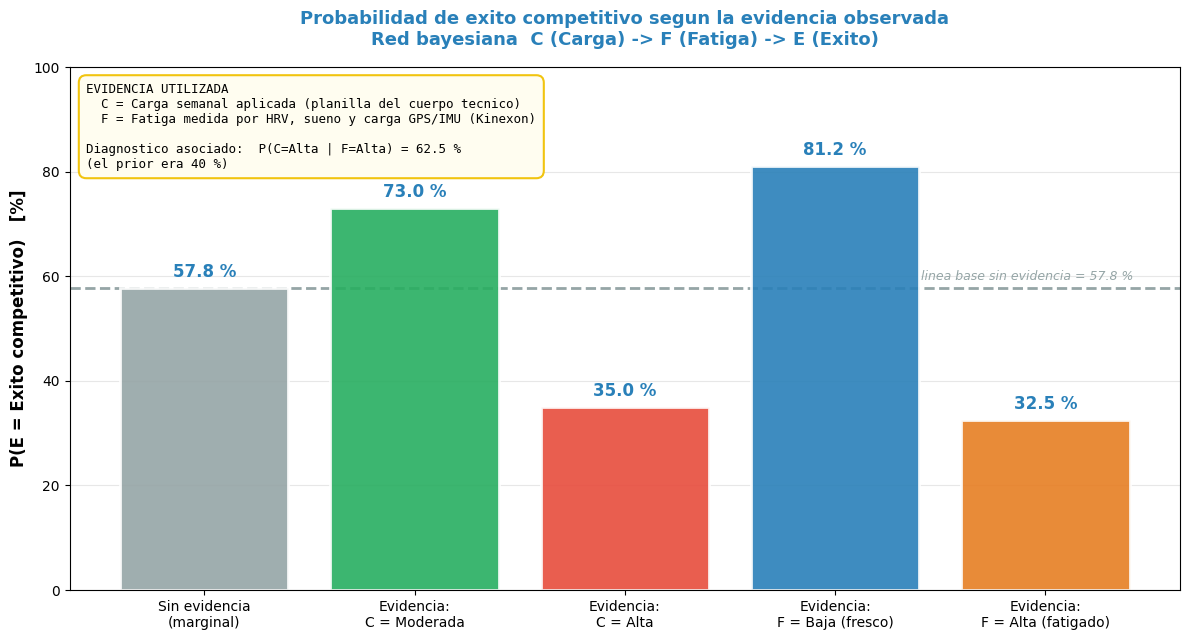

Figura guardada como 'bayes_bars.png' (archivo obligatorio del Parcial Practico 1)


In [ ]:
# ============================================================
# CELDA 10 — Grafico de barras de las probabilidades calculadas
#            (se guarda como bayes_bars.png para el parcial)
# ============================================================

escenarios = [
    ("Sin evidencia\n(marginal)",      p_exito_marginal, GRIS),
    ("Evidencia:\nC = Moderada",       p_exito_mod,      VERDE),
    ("Evidencia:\nC = Alta",           p_exito_alta,     ROJO),
    ("Evidencia:\nF = Baja (fresco)",  p_exito_fat_baja, AZUL),
    ("Evidencia:\nF = Alta (fatigado)",p_exito_fat_alta, NARANJA),
]

nombres = [e[0] for e in escenarios]
valores = [e[1] * 100 for e in escenarios]
colores = [e[2] for e in escenarios]

fig, ax = plt.subplots(figsize=(12, 6.5))
barras = ax.bar(nombres, valores, color=colores, alpha=0.9,
                edgecolor="white", linewidth=2)

# Valor encima de cada barra
for b, v in zip(barras, valores):
    ax.annotate(f"{v:.1f} %",
                (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", xytext=(0, 5),
                textcoords="offset points",
                fontsize=12, fontweight="bold", color=AZUL)

# Linea de referencia: la marginal
ax.axhline(p_exito_marginal * 100, color=GRIS, linestyle="--",
           linewidth=2, zorder=0)
ax.annotate(f"linea base sin evidencia = {p_exito_marginal*100:.1f} %",
            xy=(4.42, p_exito_marginal * 100 + 1.4), ha="right",
            fontsize=9, color=GRIS, style="italic")

ax.set_ylabel("P(E = Exito competitivo)   [%]",
              fontsize=12, fontweight="bold")
ax.set_ylim(0, 100)
ax.set_title(
    "Probabilidad de exito competitivo segun la evidencia observada\n"
    "Red bayesiana  C (Carga) -> F (Fatiga) -> E (Exito)",
    fontsize=13, fontweight="bold", color=AZUL, pad=16)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# La evidencia usada, escrita DENTRO del grafico (lo exige el parcial)
texto_evidencia = (
    "EVIDENCIA UTILIZADA\n"
    "  C = Carga semanal aplicada (planilla del cuerpo tecnico)\n"
    "  F = Fatiga medida por HRV, sueno y carga GPS/IMU (Kinexon)\n"
    f"\nDiagnostico asociado:  P(C=Alta | F=Alta) = {post_c_alta*100:.1f} %\n"
    f"(el prior era {P_C['Alta']*100:.0f} %)"
)
ax.text(0.015, 0.97, texto_evidencia, transform=ax.transAxes,
        fontsize=9, va="top", ha="left", family="monospace",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#FFFDF0",
                  edgecolor=AMARILLO, linewidth=1.5))

plt.tight_layout()
plt.savefig("bayes_bars.png", dpi=140, bbox_inches="tight")
plt.show()

print("Figura guardada como 'bayes_bars.png' "
      "(archivo obligatorio del Parcial Practico 1)")

---

# 4. Los tres tipos de razonamiento

El material de clase distingue tres formas de razonar sobre una misma red. Ya usamos dos; aquí las
juntamos y añadimos la tercera, que es la más interesante.

| Tipo | Dirección | Pregunta clave |
|---|---|---|
| **Causal** | ↓ (causa → efecto) | *"Si pasa esto, ¿qué pasará?"* |
| **Diagnóstico** | ↑ (efecto → causa) | *"Si vi esto, ¿qué lo causó?"* |
| **Intercausal** *(explaining away)* | ↔ (entre causas) | *"¿Esta evidencia descarta la otra posibilidad?"* |

## El caso intercausal: una segunda causa de la fatiga

Para mostrar *explaining away* necesitamos que la fatiga tenga **dos causas que compiten**.
Añadimos temporalmente una variable:

- **V** = el atleta hizo un **viaje largo** esta semana (`Si` / `No`), con `P(V=Si) = 0.20`.

```
        C (Carga)        V (Viaje largo)
              \           /
               v         v
                 F (Fatiga)
```

Es la estructura del ejemplo de clase de la alarma del banco: la alarma suena (`F`) y hay dos
explicaciones posibles, *"intento de robo"* (`C`) y *"fallo del sensor"* (`V`). Confirmar una
**baja** la probabilidad de la otra.

In [ ]:
# ============================================================
# CELDA 11 — Razonamiento intercausal (explaining away)
# ============================================================
# Extension temporal de la red: la fatiga tiene DOS causas que
# compiten entre si.
#
#      C (Carga alta)      V (Viaje largo)
#              \            /
#               v          v
#                 F (Fatiga)
#
# Las CPTs estan calibradas para que, al marginalizar V, se
# recupere aproximadamente la P(F|C) de la red principal:
#     P(F=Alta|C=Alta)     = 0.2*0.90 + 0.8*0.70 = 0.74  (red simple: 0.75)
#     P(F=Alta|C=Moderada) = 0.2*0.60 + 0.8*0.22 = 0.296 (red simple: 0.30)
# ============================================================

P_V = {"Si": 0.20, "No": 0.80}

P_F_dado_CV = {
    ("Alta",     "Si"): 0.90,   # carga alta + viaje  -> casi seguro fatigado
    ("Alta",     "No"): 0.70,
    ("Moderada", "Si"): 0.60,   # el viaje solo ya fatiga bastante
    ("Moderada", "No"): 0.22,
}


def p_carga_alta_dado(f_obs="Alta", v_obs=None):
    """P(C=Alta | F=f_obs [, V=v_obs]) en la red extendida."""
    vs = VALORES_C
    valores_v = [v_obs] if v_obs else list(P_V)

    def peso(c, v):
        pf = P_F_dado_CV[(c, v)] if f_obs == "Alta" else 1 - P_F_dado_CV[(c, v)]
        return P_C[c] * P_V[v] * pf

    num = sum(peso("Alta", v) for v in valores_v)
    den = sum(peso(c, v) for c in vs for v in valores_v)
    return num / den


sin_info  = p_carga_alta_dado("Alta")
con_viaje = p_carga_alta_dado("Alta", "Si")
sin_viaje = p_carga_alta_dado("Alta", "No")

print("=" * 70)
print("  RAZONAMIENTO INTERCAUSAL  —  'Explaining away'")
print("=" * 70)
print(f"""
  Situacion: el atleta llega FATIGADO (F = Alta).
  Hay dos explicaciones posibles que compiten:
      C = se le aplico carga alta
      V = hizo un viaje largo

  {'-'*66}

  1) Solo sabemos que esta fatigado
       P(C=Alta | F=Alta) = {sin_info*100:.1f} %
       -> La sospecha sobre la carga sube desde el prior de {P_C['Alta']*100:.0f} %.

  2) Ademas CONFIRMAMOS el viaje largo    (V = Si)
       P(C=Alta | F=Alta, V=Si) = {con_viaje*100:.1f} %
       -> La sospecha BAJA {(sin_info-con_viaje)*100:.1f} puntos.
          El viaje "explica" la fatiga y DESCARTA parcialmente
          a la carga. Esto es explaining away.

  3) O DESCARTAMOS el viaje largo         (V = No)
       P(C=Alta | F=Alta, V=No) = {sin_viaje*100:.1f} %
       -> La sospecha SUBE {(sin_viaje-sin_info)*100:.1f} puntos.
          Si no hubo viaje, la carga queda como unica explicacion.

  {'='*66}
  POR QUE IMPORTA EN NUESTRO SECTOR
  {'='*66}

  Sin este razonamiento, el sistema culparia a la planificacion
  cada vez que un atleta llega fatigado, y el preparador fisico
  terminaria bajando cargas que no eran el problema.

  Con el, el agente distingue: "esta fatigado, pero volo 9 horas
  el martes; la carga no era el problema". Es exactamente el
  ejemplo de la alarma del banco visto en clase: confirmar el
  fallo del sensor baja la probabilidad del robo.
""")

  RAZONAMIENTO INTERCAUSAL  —  'Explaining away'

  Situacion: el atleta llega FATIGADO (F = Alta).
  Hay dos explicaciones posibles que compiten:
      C = se le aplico carga alta
      V = hizo un viaje largo

  ------------------------------------------------------------------

  1) Solo sabemos que esta fatigado
       P(C=Alta | F=Alta) = 62.5 %
       -> La sospecha sobre la carga sube desde el prior de 40 %.

  2) Ademas CONFIRMAMOS el viaje largo    (V = Si)
       P(C=Alta | F=Alta, V=Si) = 50.0 %
       -> La sospecha BAJA 12.5 puntos.
          El viaje "explica" la fatiga y DESCARTA parcialmente
          a la carga. Esto es explaining away.

  3) O DESCARTAMOS el viaje largo         (V = No)
       P(C=Alta | F=Alta, V=No) = 68.0 %
       -> La sospecha SUBE 5.5 puntos.
          Si no hubo viaje, la carga queda como unica explicacion.

  POR QUE IMPORTA EN NUESTRO SECTOR

  Sin este razonamiento, el sistema culparia a la planificacion
  cada vez que un atleta llega fatiga

---

# 5. Conexión con la Guía 5: Min-Max vs Bayes

Esta sección no la pide la actividad, pero es la que conecta la guía con el resto del curso y con el
parcial.

En la Guía 5 el árbol Min-Max asumía que el organismo (**MIN**) es un **adversario perfecto**:
siempre responde con la fatiga que más nos perjudica. Ahora sabemos qué tan probable es cada
respuesta, así que podemos calcular la **utilidad esperada** en lugar de la **garantizada**:

$$U_{\text{esperada}}(C) = \sum_F P(F \mid C)\cdot U_{\text{MAX}}(C, F)$$

donde $U_{\text{MAX}}(C,F)$ es el valor que MAX obtiene en ese nodo (ya calculado en la Guía 5).

In [ ]:
# ============================================================
# CELDA 12 — Min-Max (garantizado) vs Bayes (esperado)
# ============================================================
# Valores tomados del arbol Min-Max de la Guia 5:
#
#   U = (Rendimiento x 4) - (CO2 x 2) - (Riesgo_lesion x 3)
#       + (Recuperacion x 2)
#
# En cada nodo de nivel 2 (fatiga), MAX ya eligio lo mejor entre
# "Jugar" y "Descansar":
# ============================================================

# Valor que consigue MAX en cada nodo de fatiga (Guia 5)
U_MAX = {
    ("Alta",     "Alta"): -1,   # max(Jugar=-27, Descansar= -1)
    ("Alta",     "Baja"): 21,   # max(Jugar=  4, Descansar= 21)
    ("Moderada", "Alta"): 19,   # max(Jugar=  9, Descansar= 19)
    ("Moderada", "Baja"): 42,   # max(Jugar= 42, Descansar= 41)
}

filas_cmp = []
for c in VALORES_C:
    # Min-Max: el organismo concede lo peor para nosotros
    garantizado = min(U_MAX[(c, f)] for f in VALORES_F)
    peor_f = min(VALORES_F, key=lambda f: U_MAX[(c, f)])
    # Bayes: ponderamos por la probabilidad real de cada respuesta
    esperado = sum(P_F_dado_C[c][f] * U_MAX[(c, f)] for f in VALORES_F)

    filas_cmp.append({
        "Carga":                    c,
        "U si F=Alta":              U_MAX[(c, "Alta")],
        "U si F=Baja":              U_MAX[(c, "Baja")],
        "P(F=Alta|C)":              P_F_dado_C[c]["Alta"],
        "Min-Max (garantizado)":    garantizado,
        "Bayes (esperado)":         round(esperado, 2),
        "P(E=Exito|C)":             f"{p_exito_dado_carga(c, verbose=False)*100:.1f} %",
    })

tabla_cmp = pd.DataFrame(filas_cmp)

print("=" * 88)
print("  MIN-MAX (decision garantizada)  vs  BAYES (decision esperada)")
print("=" * 88)
print(tabla_cmp.to_string(index=False))

dec_minmax = max(filas_cmp, key=lambda r: r["Min-Max (garantizado)"])
dec_bayes  = max(filas_cmp, key=lambda r: r["Bayes (esperado)"])

print(f"""
  {'='*84}

  Decision Min-Max : Carga {dec_minmax['Carga']}   (valor garantizado {dec_minmax['Min-Max (garantizado)']:+})
  Decision Bayes   : Carga {dec_bayes['Carga']}   (valor esperado    {dec_bayes['Bayes (esperado)']:+})

  -> Las dos coinciden en QUE hacer: carga moderada.

  Pero no en CUANTO vale. Min-Max promete {dec_minmax['Min-Max (garantizado)']:+}, Bayes espera
  {dec_bayes['Bayes (esperado)']:+.1f}: casi el doble. La diferencia es el precio del
  pesimismo. Min-Max supone que el organismo SIEMPRE responde
  mal; la red bayesiana sabe que con carga moderada eso solo
  pasa el {P_F_dado_C['Moderada']['Alta']*100:.0f} % de las veces.

  {'='*84}
  LA CONCLUSION DEL PROYECTO
  {'='*84}

    Min-Max dice que hacer cuando no puedes permitirte fallar.
    Bayes dice que esperar en promedio.
    STRIPS (Guia 5) es el plan que te lleva de una a la otra:
    bajar el CO2 acumulado para que la fatiga alta deje de ser
    lo mas probable.

    Que coincidan es tranquilizador: la decision prudente y la
    decision estadistica apuntan al mismo lado. Cuando NO
    coincidan, sabremos que estamos ante una apuesta.
""")

  MIN-MAX (decision garantizada)  vs  BAYES (decision esperada)
   Carga  U si F=Alta  U si F=Baja  P(F=Alta|C)  Min-Max (garantizado)  Bayes (esperado) P(E=Exito|C)
    Alta           -1           21         0.75                     -1               4.5       35.0 %
Moderada           19           42         0.30                     19              35.1       73.0 %


  Decision Min-Max : Carga Moderada   (valor garantizado +19)
  Decision Bayes   : Carga Moderada   (valor esperado    +35.1)

  -> Las dos coinciden en QUE hacer: carga moderada.

  Pero no en CUANTO vale. Min-Max promete +19, Bayes espera
  +35.1: casi el doble. La diferencia es el precio del
  pesimismo. Min-Max supone que el organismo SIEMPRE responde
  mal; la red bayesiana sabe que con carga moderada eso solo
  pasa el 30 % de las veces.

  LA CONCLUSION DEL PROYECTO

    Min-Max dice que hacer cuando no puedes permitirte fallar.
    Bayes dice que esperar en promedio.
    STRIPS (Guia 5) es el plan que te lleva de

---

# 6. Conclusiones

### Sobre los objetivos de la actividad

1. **Construcción de la red.** Tres variables —`Carga semanal`, `Fatiga` y `Éxito competitivo`—
   conectadas en un DAG con tres CPTs: `P(C)`, `P(F|C)` y `P(E|C,F)`. Las variables son
   deliberadamente las mismas de los dos primeros niveles del árbol Min-Max de la Guía 5.

2. **Probabilidad conjunta.** `P(C=Moderada, F=Baja, E=Exito) = 0.357` → **35.7 %**. El escenario
   ideal ocurre algo más de un tercio de las semanas. Su opuesto,
   `P(C=Alta, F=Alta, E=Exito) = 0.075` → **7.5 %**, ocurre 1 de cada 13. En el árbol Min-Max esas
   mismas combinaciones valían **+42** y **−27**: los dos modelos ordenan el mundo igual.

3. **Inferencia con evidencia parcial.** La expectativa de éxito pasa de **57.8 %** sin evidencia a
   **32.5 %** si el atleta llega fatigado y a **81.2 %** si llega fresco. Y la misma observación
   actualiza hacia atrás la sospecha sobre la carga: de **40 %** a **62.5 %**.

### Lo que hay que llevarse

> **Una red bayesiana no predice el futuro: reparte la creencia.**
> Antes de mirar los sensores, nuestra expectativa de éxito era una sola cifra (57.8 %). Después de
> mirarlos, se parte en dos mundos muy distintos (32.5 % vs 81.2 %), y además nos dice algo que no
> habíamos preguntado: qué tan probable es que la culpa sea de la carga que nosotros pusimos.

Eso es lo que le faltaba a los otros dos métodos del curso. STRIPS planifica como si nada pudiera
salir mal. Min-Max decide como si todo fuera a salir mal. **Bayes es el único de los tres que
cambia de opinión cuando llega un dato nuevo** — y por eso es el que le permite al agente del
parcial observar antes de decidir.

### Archivos generados

| Archivo | Uso |
|---|---|
| `red_bayesiana.png` | Diagrama de la red con sus CPTs |
| `bayes_bars.png` | **Obligatorio en el Parcial Práctico 1** |

### Fuentes de los datos

- **Fatiga:** variabilidad de la frecuencia cardíaca (HRV), calidad de sueño y carga acumulada
  medida con GPS/IMU — Kinexon, Catapult Sports.
- **Carga semanal:** planillas de planificación del cuerpo técnico.
- **Éxito competitivo:** registro histórico de disponibilidad y rendimiento en partido.
- **Estructura metodológica:** ejemplos resueltos del material de clase
  (`PLANIFIC BAYESIANO.md`): diagnóstico médico, clima/paraguas, fraude bancario, batería del coche
  y el caso de turismo `Clima → Transporte → Actividad`.